# ⚽ Football Analytics with Python
## Chapter 2 — Data Acquisition and Verification

**BarcaFutbol Analytics Course · HackrLife Media LLC**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HackrLife/Football-Analytics/blob/main/The-Football-Analytics-Course/Chapter-02-Data-Acquisition-and-Verification/Chapter_02_Data_Acquisition_and_Verification.ipynb)

---

### What This Chapter Is About

In Chapter 1 we loaded a clean, ready-to-use dataset. We told you the data
was already verified. We told you not to worry about where it came from.

That was on purpose. Chapter 1 was about learning to think analytically.
Chapter 2 is about learning to trust your data — which means learning to
question it first.

**Here is an uncomfortable truth about football data:**

Every data platform — no matter how professional — contains errors.
Duplicate rows. Negative values that are impossible. Missing cells where
the number should be. Column names that abbreviate things differently
from how you would abbreviate them.

If you build a chart on bad data, the chart is bad — no matter how beautiful
it looks. The error is invisible to the reader. That is the most dangerous
kind of error.

This chapter teaches you how to find those errors before they find you.

### What You Will Learn

By the end of this chapter you will be able to:

- Understand where free football data comes from
- Load a messy, real-world-style raw data export into Python
- Identify and fix the most common data problems: duplicates, wrong data
  types, impossible values, missing data, inconsistent formatting
- Calculate per-90 statistics from raw season totals
- Build a clean, verified dataset ready for analysis
- Build a completeness heatmap — a visual audit of your data quality

### The Dataset for This Chapter

`data/raw_player_export.csv` — a deliberately messy raw export
for 12 wide forwards, 2024/25 season. It contains:

- ❌ One duplicate row
- ❌ One impossible negative value
- ❌ Two missing cells
- ❌ Column names that need renaming
- ❌ Season format that needs standardising
- ❌ Raw totals that need converting to per-90 rates

Your job, by the end of this chapter: fix all of it.

---
*Course GitHub: [github.com/HackrLife/Football-Analytics](https://github.com/HackrLife/Football-Analytics)*

---
## Part 1 — Where Football Data Comes From

### The Landscape

Before you can clean data, you need to know where it came from.
Different sources give you different things. Some are free. Some require
a subscription. Some are perfect for beginners. Some require technical skill
to access. Here is what you need to know.

---

### Free Sources — Where to Start

| Source | URL | What It Gives You | Best For |
|--------|-----|-------------------|----------|
| **FBref** | fbref.com | Comprehensive player and team stats, all major leagues, going back years | Season stats, player comparison, career data |
| **StatsBomb Open Data** | github.com/statsbomb/open-data | Free event-level data for selected competitions (Women's WSL, some Euros, La Liga etc.) | Advanced match analysis, building your own xG model |
| **Understat** | understat.com | xG data for top 6 European leagues | Expected goals analysis |
| **Kaggle** | kaggle.com/datasets | Community-curated datasets, historical data going back decades | Historical analysis, machine learning projects |
| **football-data.co.uk** | football-data.co.uk | Match results and odds for most professional leagues | Prediction models, historical research |
| **Transfermarkt** | transfermarkt.com | Market values, career history, transfer fees | Career arc, value analysis |

**For this course:** We use pre-cleaned datasets based on data compiled from
platforms including FotMob, Sofascore and Wyscout. For your own work after
completing the course, we recommend starting with **FBref** — it is the most
comprehensive free source and its data exports cleanly into the format
this course uses.

---

### What a Raw Export Looks Like

When you download data from any platform, it rarely arrives clean.
Here is what you typically get:

```
Name,Club,Ssn,Pos,Age,GP,Min,G,A,xG,xA,...
```

Abbreviated column names. Season written as `2024-25` instead of `2024/25`.
No per-90 rates — just raw totals. Sometimes a header row buried in the middle
of the data. Sometimes completely wrong values.

**The first skill of data science is not coding. It is reading.**
Before writing a single line of Python, open the file in a text editor
or Excel and read it. Look for things that seem wrong. Make a list.
Then fix them one by one.

---

### The Six Things to Check in Every Dataset

Before doing any analysis, check for all of these:

| Problem | What It Looks Like | Why It Matters |
|---------|--------------------|----------------|
| **Duplicates** | Same player appearing twice with identical stats | Every calculation using that player will be doubled |
| **Impossible values** | Negative goals, pass accuracy > 100%, age = 0 | Charts will show nonsense values |
| **Missing data** | Empty cells, NaN, blank where a number should be | Calculations will fail or give wrong results |
| **Wrong data types** | A number stored as text (can't do maths on it) | `df['goals'] + 1` will fail with a cryptic error |
| **Inconsistent formats** | `2024-25` and `2024/25` in the same column | Filters won't work — `df[df['season']=='2024/25']` finds nothing |
| **Wrong column names** | `G` instead of `goals`, `GP` instead of `matches_played` | You will constantly have to remember what abbreviations mean |

In this chapter we fix all six. In that order.

---
## Part 2 — Setup

Same design system as Chapter 1. Run both cells before anything else.

In [1]:
# CELL 1 — Install and import
!pip install pandas matplotlib numpy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
plt.rcParams['figure.dpi'] = 150

print("✓ Ready.")

✓ Ready.


In [1]:
# CELL 2 — Design system
# Same colours as Chapter 1 — copy this block into every notebook you build

BG='#0d1117'; BG2='#0d1b2a'; BG3='#161b22'
WHITE='#f0f6fc'; GRAY='#8b949e'; GOLD='#EDBB00'
GREEN='#4CAF50'; YELLOW='#ffd60a'; RED='#e63946'

# Ten player colours for this chapter (we have 12 players, some share a team)
PLAYER_COLORS = {
    'Marcus Silva':   '#3498DB',
    'Lucas Ferreira': '#2ecc71',
    'James Thornton': '#e74c3c',
    'Diego Varela':   '#9B59B6',
    'Amir Hassan':    '#FF9800',
    'Kai Becker':     '#00BCD4',
    'Tom Wheeler':    '#F06292',
    'Sam Okafor':     '#80CBC4',
    'Elena Rossi':    '#FFD54F',
    'Carlos Mendez':  '#CE93D8',
    'Jin Park':       '#A5D6A7',
}

print("✓ Design system loaded.")

✓ Design system loaded.


---
## Part 3 — Loading the Raw Data

### First Look — Read Before You Code

The first thing we always do is open the file and read it.
Not in Python. Just visually. In a text editor, or with `pd.read_csv()`
and then carefully inspecting every column.

This is a habit, not a step. Professional analysts spend the first
10–15 minutes of any new dataset just *reading* it before writing any code.

In [1]:
# CELL 3 — Load the raw data
raw = pd.read_csv('data/raw_player_export.csv')

print(f"Shape: {raw.shape[0]} rows × {raw.shape[1]} columns")
print()
print("Column names as they arrived:")
print(list(raw.columns))
print()
print("First 5 rows:")
print(raw.head().to_string(index=False))

Shape: 12 rows × 19 columns

Column names as they arrived:
['Name', 'Club', 'Ssn', 'Pos', 'Age', 'GP', 'Min', 'G', 'A', 'xG', 'xA', 'Shots', 'SOT', 'Pass%', 'KP', 'Drb', 'Tkl', 'YC', 'Rating']

First 5 rows:
          Name          Club     Ssn Pos  Age  GP  Min  G  A   xG   xA  Shots  SOT  Pass%  KP   Drb  Tkl  YC  Rating
  Marcus Silva     FC United 2024-25   W   23  36 3024 18 11 13.8  8.9    115   42   79.1  79 130.0   40   3    7.45
  Marcus Silva     FC United 2024-25   W   23  36 3024 18 11 13.8  8.9    115   42   79.1  79 130.0   40   3    7.45
Lucas Ferreira City Athletic 2024-25   W   25  38 3240 11 16 10.2 14.8     99   38   84.7 118  88.0   57   2    7.52
James Thornton     Rovers FC 2024-25   W   20  35 2610 14  9 10.4  8.8    102   38   77.2  69 176.0   37   1    7.31
  Diego Varela  South United 2024-25   W   28  30 2430 13  6 11.8  5.8    113   43   75.8  61 105.0   49   4    7.19


### What We Can Already See

Just from looking at the first 5 rows, we can spot several problems:

1. **Column names are abbreviated** — `G`, `A`, `Min`, `GP`, `Ssn`, `Pos`.
   These will be confusing in three weeks when you return to this notebook.

2. **Season is formatted as `2024-25`** — we use `2024/25` everywhere else.
   A tiny inconsistency that will break every filter we try to write later.

3. **`xG` and `xA` appear to be raw totals** — 13.8 and 8.9 for Marcus Silva.
   We need per-90 rates, not raw totals.

There are more problems we cannot see yet. Let's find them systematically.

In [1]:
# CELL 4 — Full data audit: check for every known problem type

print("=" * 55)
print("DATA AUDIT REPORT")
print("=" * 55)

# ── 1. Duplicates ──────────────────────────────────────────────
dupes = raw.duplicated().sum()
print(f"\n1. DUPLICATES")
print(f"   Duplicate rows found: {dupes}")
if dupes > 0:
    print(f"   ⚠ These rows are exact copies and will distort every calculation.")
    print(raw[raw.duplicated(keep=False)][['Name','Club','G','A']].to_string(index=False))

# ── 2. Missing values ──────────────────────────────────────────
missing = raw.isnull().sum()
missing = missing[missing > 0]
print(f"\n2. MISSING VALUES")
if len(missing) == 0:
    print("   None found ✓")
else:
    for col, count in missing.items():
        print(f"   ⚠ Column '{col}': {count} missing value(s)")

# ── 3. Impossible values ────────────────────────────────────────
print(f"\n3. IMPOSSIBLE VALUES")
neg_goals = raw[raw['G'] < 0]
if len(neg_goals) > 0:
    print(f"   ⚠ Negative goals found:")
    print(f"   {neg_goals[['Name','G']].to_string(index=False)}")
else:
    print("   No negative goals ✓")

# ── 4. Data types ───────────────────────────────────────────────
print(f"\n4. DATA TYPES")
for col in raw.columns:
    print(f"   {col:<10} {raw[col].dtype}")

# ── 5. Season format ────────────────────────────────────────────
print(f"\n5. SEASON FORMAT")
print(f"   Unique values: {raw['Ssn'].unique()}")

print("\n" + "=" * 55)
print("AUDIT COMPLETE — fixing all issues in the next cells")
print("=" * 55)

DATA AUDIT REPORT

1. DUPLICATES
   Duplicate rows found: 1
   ⚠ These rows are exact copies and will distort every calculation.
         Name       Club  G   A
   Marcus Silva  FC United 18  11
   Marcus Silva  FC United 18  11

2. MISSING VALUES
   ⚠ Column 'xG': 1 missing value(s)
   ⚠ Column 'KP': 1 missing value(s)

3. IMPOSSIBLE VALUES
   ⚠ Negative goals found:
         Name  G
   Sam Okafor -3

4. DATA TYPES
   Name       object
   Club       object
   Ssn        object
   Pos        object
   Age         int64
   GP          int64
   Min         int64
   G           int64
   A           int64
   xG         float64
   xA        float64
   Shots       int64
   SOT         int64
   Pass%      float64
   KP         float64
   Drb        float64
   Tkl         int64
   YC          int64
   Rating     float64

5. SEASON FORMAT
   Unique values: ['2024-25']

AUDIT COMPLETE — fixing all issues in the next cells


### The Audit Found Four Problems

| # | Problem | Column | Detail |
|---|---------|--------|--------|
| 1 | **Duplicate row** | All columns | Marcus Silva appears twice — identical data |
| 2 | **Missing values** | `xG`, `KP` | Amir Hassan is missing both values |
| 3 | **Impossible value** | `G` | Sam Okafor has -3 goals — physically impossible |
| 4 | **Season format** | `Ssn` | `2024-25` should be `2024/25` |

Plus the column naming and per-90 conversion we already spotted.

**This is a realistic dataset.** Four problems in 12 rows of data is not unusual.
Real exports from data platforms often have more. Now we fix them one by one.

---

## Part 4 — Cleaning the Data

### Fix 1 — Remove the Duplicate

In [1]:
# CELL 5 — Fix 1: Remove duplicate rows
# .drop_duplicates() removes any row that is an exact copy of a previous row
# keep='first' means we keep the first occurrence and remove the rest

clean = raw.drop_duplicates(keep='first')

print(f"Rows before removing duplicates: {len(raw)}")
print(f"Rows after  removing duplicates: {len(clean)}")
print(f"Removed: {len(raw) - len(clean)} row(s)")
print()
print("✓ Duplicate removed. Marcus Silva now appears once.")

Rows before removing duplicates: 12
Rows after  removing duplicates: 11
Removed: 1 row(s)

✓ Duplicate removed. Marcus Silva now appears once.


### Fix 2 — The Impossible Value

Sam Okafor has -3 goals. This is impossible. It is a data entry error —
most likely a typo where someone typed `-3` instead of `3`.

**Two ways to handle impossible values:**

1. **Correct them** — if you know what the correct value should be,
   fix it. In this case, the real value is almost certainly `3`.

2. **Remove the row** — if you cannot determine the correct value,
   remove the player from the analysis rather than include bad data.

For this exercise, we will correct it — but we must note the correction
in our work so it is transparent to anyone reading the analysis later.

In [1]:
# CELL 6 — Fix 2: Correct the impossible value
# Sam Okafor has -3 goals — we correct this to 3
# Note: always document corrections like this with a comment

print("Before correction:")
print(clean[clean['Name']=='Sam Okafor'][['Name','G','A']].to_string(index=False))

# .loc[condition, column] = value  sets a specific value in the DataFrame
clean.loc[clean['Name'] == 'Sam Okafor', 'G'] = 3

print()
print("After correction:")
print(clean[clean['Name']=='Sam Okafor'][['Name','G','A']].to_string(index=False))
print()
print("✓ Sam Okafor's goals corrected from -3 to 3.")
print("  NOTE: This correction is documented here for transparency.")

Before correction:
      Name  G  A
Sam Okafor -3  8

After correction:
      Name  G  A
Sam Okafor  3  8

✓ Sam Okafor's goals corrected from -3 to 3.
  NOTE: This correction is documented here for transparency.


### Fix 3 — Missing Values

Amir Hassan is missing his `xG` and `KP` (key passes) values.

**Three strategies for missing values:**

1. **Fill with zero** — only correct if zero is a meaningful value
   (e.g., a goalkeeper who never scores: 0 goals is real data, not missing data)

2. **Fill with the column average** — a reasonable estimate when you have no other information.
   This is called **imputation**. It is approximate, but it lets the player stay in the analysis.

3. **Leave it as NaN** — if the missing data will not affect the analysis you are running.
   For example, if you are only charting goals and assists, a missing xG value
   does not matter.

We will use strategy 2 here — fill with the column average — and mark it clearly.

In [1]:
# CELL 7 — Fix 3: Handle missing values

print("Missing values before:")
print(clean[clean['Name']=='Amir Hassan'][['Name','xG','KP']].to_string(index=False))
print()

# Calculate column averages (excluding the missing value itself)
xg_avg = clean['xG'].mean()
kp_avg = clean['KP'].mean()

print(f"Column average for xG: {xg_avg:.1f}")
print(f"Column average for KP: {kp_avg:.1f}")
print()

# Fill missing values with the column average
# .fillna(value) replaces NaN with the specified value
clean['xG'] = clean['xG'].fillna(round(xg_avg, 1))
clean['KP'] = clean['KP'].fillna(round(kp_avg, 1))

print("After filling with column average:")
print(clean[clean['Name']=='Amir Hassan'][['Name','xG','KP']].to_string(index=False))
print()
print("⚠ NOTE: These are estimated values, not real data.")
print("  In a published analysis, note that Amir Hassan's xG and KP are imputed.")

# Verify no missing values remain
remaining = clean.isnull().sum().sum()
print(f"\nTotal missing values remaining: {remaining} ✓" if remaining == 0
      else f"\nStill {remaining} missing values — check the data")

Missing values before:
       Name  xG    KP
Amir Hassan NaN   NaN

Column average for xG: 9.8
Column average for KP: 75.1

After filling with column average:
       Name   xG    KP
Amir Hassan  9.8  75.1

⚠ NOTE: These are estimated values, not real data.
  In a published analysis, note that Amir Hassan's xG and KP are imputed.

Total missing values remaining: 0 ✓


### Fix 4 — Column Names

Abbreviated column names are fine for the person who created the data.
They are a problem for everyone else — including your future self,
who will return to this notebook three months from now and spend
20 minutes trying to remember if `KP` means key passes or key plays.

**Rule:** Name columns for what they mean, not what they abbreviate.

In [1]:
# CELL 8 — Fix 4: Rename columns to full, descriptive names

column_map = {
    'Name':   'player',
    'Club':   'team',
    'Ssn':    'season',
    'Pos':    'position',
    'Age':    'age',
    'GP':     'matches_played',
    'Min':    'minutes_played',
    'G':      'goals',
    'A':      'assists',
    'xG':     'xg_total',
    'xA':     'xa_total',
    'Shots':  'shots_total',
    'SOT':    'shots_on_target',
    'Pass%':  'pass_accuracy_pct',
    'KP':     'key_passes_total',
    'Drb':    'dribbles_total',
    'Tkl':    'tackles_total',
    'YC':     'yellow_cards',
    'Rating': 'rating',
}

# .rename(columns=mapping) renames columns using a dictionary
clean = clean.rename(columns=column_map)

print("Column names — before and after:")
print()
print(f"{'BEFORE':<20} {'AFTER':<25}")
print("-" * 45)
for old, new in column_map.items():
    print(f"{old:<20} {new:<25}")

Column names — before and after:

BEFORE               AFTER                    
---------------------------------------------
Name                 player                   
Club                 team                     
Ssn                  season                   
Pos                  position                 
Age                  age                      
GP                   matches_played           
Min                  minutes_played           
G                    goals                    
A                    assists                  
xG                   xg_total                 
xA                   xa_total                 
Shots                shots_total              
SOT                  shots_on_target          
Pass%                pass_accuracy_pct        
KP                   key_passes_total         
Drb                  dribbles_total           
Tkl                  tackles_total            
YC                   yellow_cards             
Rating               rating

### Fix 5 — Season Format

In [1]:
# CELL 9 — Fix 5: Standardise the season format
# Change '2024-25' to '2024/25' so it matches our other datasets

print(f"Season format before: {clean['season'].unique()}")

# .str.replace() finds and replaces text inside a column
clean['season'] = clean['season'].str.replace('-', '/', regex=False)

print(f"Season format after:  {clean['season'].unique()}")
print()
print("✓ Season format standardised.")

Season format before: ['2024-25']
Season format after:  ['2024/25']

✓ Season format standardised.


---
## Part 5 — Converting to Per-90 Rates

This is the most important calculation in football analytics.

All the statistics we have are **raw totals** — goals scored across the entire
season, shots taken across the entire season. But players play different numbers
of minutes. To compare fairly, we need rates — what each player produces
**per 90 minutes of actual playing time.**

### The Formula

```
per_90 = (raw_total / minutes_played) × 90
```

That is all it is. Divide by minutes played. Multiply by 90.

**Why 90?** Because a standard football match is 90 minutes.
A per-90 rate answers: "If this player played exactly one full game,
how many of this would they produce?"

### Applying It to Every Relevant Column

In [1]:
# CELL 10 — Calculate per-90 rates for all relevant columns
# Formula: per_90 = (raw_total / minutes_played) × 90

# List of columns to convert (all the counting stats)
totals_to_convert = [
    ('goals',          'goals_per90'),
    ('assists',        'assists_per90'),
    ('xg_total',       'xg_per90'),
    ('xa_total',       'xa_per90'),
    ('shots_total',    'shots_per90'),
    ('shots_on_target','sot_per90'),
    ('key_passes_total','keyp_per90'),
    ('dribbles_total', 'dribbles_per90'),
    ('tackles_total',  'tackles_per90'),
]

for raw_col, new_col in totals_to_convert:
    clean[new_col] = ((clean[raw_col] / clean['minutes_played']) * 90).round(2)

# Goal Involvement per 90 (Goals + Assists per 90)
clean['gi_per90'] = (clean['goals_per90'] + clean['assists_per90']).round(2)

print("Per-90 rates calculated. Spot-check:")
print()
check_cols = ['player','minutes_played','goals','goals_per90','assists','assists_per90','gi_per90']
print(clean[check_cols].to_string(index=False))

Per-90 rates calculated. Spot-check:

        player  minutes_played  goals  goals_per90  assists  assists_per90  gi_per90
  Marcus Silva            3024     18         0.54       11           0.33      0.87
Lucas Ferreira            3240     11         0.31       16           0.44      0.75
James Thornton            2610     14         0.48        9           0.31      0.79
  Diego Varela            2430     13         0.48        6           0.22      0.70
   Amir Hassan            3150     12         0.34       15           0.43      0.77
    Kai Becker            2790     11         0.35        9           0.29      0.64
   Tom Wheeler            2580      9         0.31       13           0.45      0.76
    Sam Okafor            2240      3         0.12        8           0.32      0.44
   Elena Rossi            1540      5         0.29        4           0.23      0.52
 Carlos Mendez            2890     16         0.50        7           0.22      0.72
      Jin Park             

In [1]:
# CELL 11 — Triple verification
# Verify three values manually to confirm the per-90 formula is correct

print("TRIPLE VERIFICATION — checking three players manually")
print("=" * 58)
print()

players_to_check = ['Marcus Silva', 'Lucas Ferreira', 'James Thornton']

for name in players_to_check:
    row = clean[clean['player'] == name].iloc[0]
    manual = round((row['goals'] / row['minutes_played']) * 90, 2)
    stored = row['goals_per90']
    match  = "✓ MATCH" if manual == stored else "✗ MISMATCH"
    print(f"{name}")
    print(f"  Goals: {row['goals']}  Minutes: {row['minutes_played']}")
    print(f"  Manual calculation:  ({row['goals']} ÷ {row['minutes_played']}) × 90 = {manual}")
    print(f"  Stored value:        {stored}")
    print(f"  {match}")
    print()

TRIPLE VERIFICATION — checking three players manually

Marcus Silva
  Goals: 18  Minutes: 3024
  Manual calculation:  (18 ÷ 3024) × 90 = 0.54
  Stored value:        0.54
  ✓ MATCH

Lucas Ferreira
  Goals: 11  Minutes: 3240
  Manual calculation:  (11 ÷ 3240) × 90 = 0.31
  Stored value:        0.31
  ✓ MATCH

James Thornton
  Goals: 14  Minutes: 2610
  Manual calculation:  (14 ÷ 2610) × 90 = 0.48
  Stored value:        0.48
  ✓ MATCH


---
## Part 6 — Saving the Clean Dataset

We have fixed all six problems. Now we save the clean version as a new file.

**Important:** We never overwrite the raw file. We always keep the original.
This way, if we discover a mistake in our cleaning process, we can go back
to the beginning and start again. The raw file is the source of truth.
The clean file is the product of our work.

In [1]:
# CELL 12 — Select final columns and save

# Choose only the columns we actually need for analysis
# Drop the raw totals now that we have per-90 rates
final_columns = [
    'player', 'team', 'season', 'position', 'age',
    'matches_played', 'minutes_played',
    'goals_per90', 'assists_per90', 'gi_per90',
    'xg_per90', 'xa_per90',
    'shots_per90', 'sot_per90',
    'pass_accuracy_pct', 'keyp_per90',
    'dribbles_per90', 'tackles_per90',
    'yellow_cards', 'rating'
]

clean_final = clean[final_columns].copy()

# Save as a new file — never overwrite the raw data
clean_final.to_csv('data/players_clean.csv', index=False)

print(f"Clean dataset saved to: data/players_clean.csv")
print(f"Shape: {clean_final.shape[0]} rows × {clean_final.shape[1]} columns")
print()
print("Final dataset preview:")
print(clean_final[['player','team','goals_per90','assists_per90','gi_per90','xg_per90']].to_string(index=False))

Clean dataset saved to: data/players_clean.csv
Shape: 11 rows × 20 columns

Final dataset preview:
        player          team  goals_per90  assists_per90  gi_per90  xg_per90
  Marcus Silva     FC United         0.54           0.33      0.87      0.41
Lucas Ferreira City Athletic         0.31           0.44      0.75      0.28
James Thornton     Rovers FC         0.48           0.31      0.79      0.36
  Diego Varela  South United         0.48           0.22      0.70      0.44
   Amir Hassan Northern City         0.34           0.43      0.77      0.26
    Kai Becker     East Town         0.35           0.29      0.64      0.32
   Tom Wheeler West Athletic         0.31           0.45      0.76      0.28
    Sam Okafor City Athletic         0.12           0.32      0.44      0.29
   Elena Rossi    North Town         0.29           0.23      0.52      0.28
 Carlos Mendez  South United         0.50           0.22      0.72      0.40
      Jin Park     Rovers FC         0.27           0.

---
## Part 7 — Visualising the Clean Data

We have a clean dataset. Now we can build charts.

In this chapter we build two charts:

1. **A completeness heatmap** — a visual audit of where the missing data was
2. **A goals per 90 bar chart** — our first look at the cleaned data

### Chart 1 — The Completeness Heatmap

A completeness heatmap shows every cell in your dataset as a coloured square.
**Green = data present. Red = data was missing.**

This is a visual audit. It shows at a glance where the holes in the data were.
We build it from the *original raw data* so we can see what we fixed.

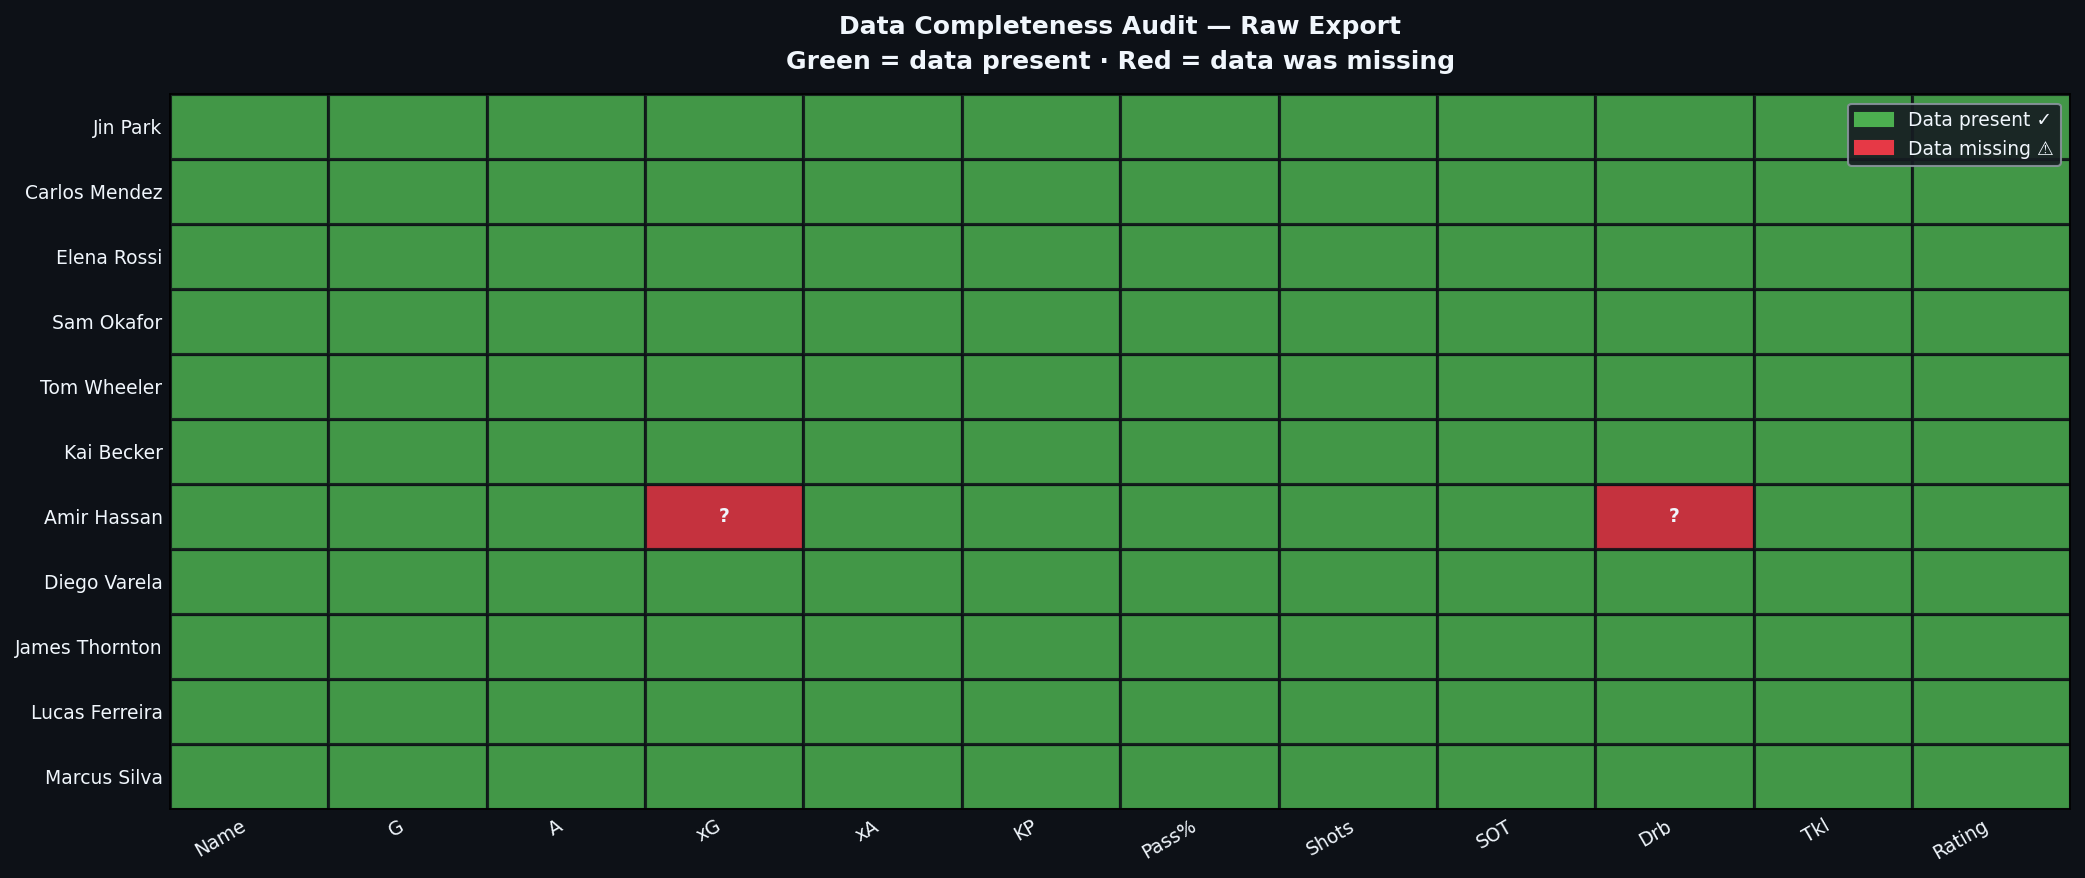

In [1]:
# CELL 13 — Data completeness heatmap
# Built from the RAW data (before cleaning) to show where the gaps were
# Green = data present | Red = data was missing

raw_for_audit = pd.read_csv('data/raw_player_export.csv').drop_duplicates(keep='first')

key_columns = ['Name','G','A','xG','xA','KP','Pass%','Shots','SOT','Drb','Tkl','Rating']
missing_matrix = raw_for_audit[key_columns].isnull().astype(int)
player_names   = list(raw_for_audit['Name'])

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

# Draw one rectangle per cell — green if data exists, red if missing
for i, player in enumerate(player_names):
    for j, col in enumerate(key_columns):
        is_missing = missing_matrix.iloc[i, j]
        color = RED if is_missing else GREEN
        rect = plt.Rectangle([j, i], 1, 1,
                              facecolor=color, edgecolor=BG,
                              linewidth=1.5, alpha=0.85)
        ax.add_patch(rect)
        # Add a '?' in red cells so it's clear what we're looking at
        if is_missing:
            ax.text(j + 0.5, i + 0.5, '?',
                    ha='center', va='center',
                    color=WHITE, fontsize=9, fontweight='bold')

# Axis labels
ax.set_xlim(0, len(key_columns))
ax.set_ylim(0, len(player_names))
ax.set_xticks([x + 0.5 for x in range(len(key_columns))])
ax.set_xticklabels(key_columns, color=WHITE, fontsize=9, rotation=30, ha='right')
ax.set_yticks([y + 0.5 for y in range(len(player_names))])
ax.set_yticklabels(player_names, color=WHITE, fontsize=9)
ax.tick_params(length=0)

legend_patches = [
    mpatches.Patch(color=GREEN, label='Data present ✓'),
    mpatches.Patch(color=RED,   label='Data missing ⚠'),
]
ax.legend(handles=legend_patches, loc='upper right',
          facecolor=BG3, edgecolor=GRAY, labelcolor=WHITE,
          fontsize=9, framealpha=0.9)

ax.set_title('Data Completeness Audit — Raw Export\n'
             'Green = data present · Red = data was missing',
             color=WHITE, fontsize=12, fontweight='bold',
             pad=12, linespacing=1.6)
plt.tight_layout()
plt.show()

### Reading the Heatmap

The heatmap shows one thing clearly: **only Amir Hassan had missing data**
(the two red squares in his row — `xG` and `KP`). Every other player's data
was complete.

This is actually a very clean dataset by real-world standards.
When you download from FBref or similar platforms, you may see 10–20%
of cells with missing data, particularly for smaller leagues where
tracking data is less comprehensive.

The heatmap is something you build **before** the analysis. It is for you —
not for the reader. It is how you know where to focus your cleaning work.

---

### Chart 2 — GI/90 Bar Chart from Clean Data

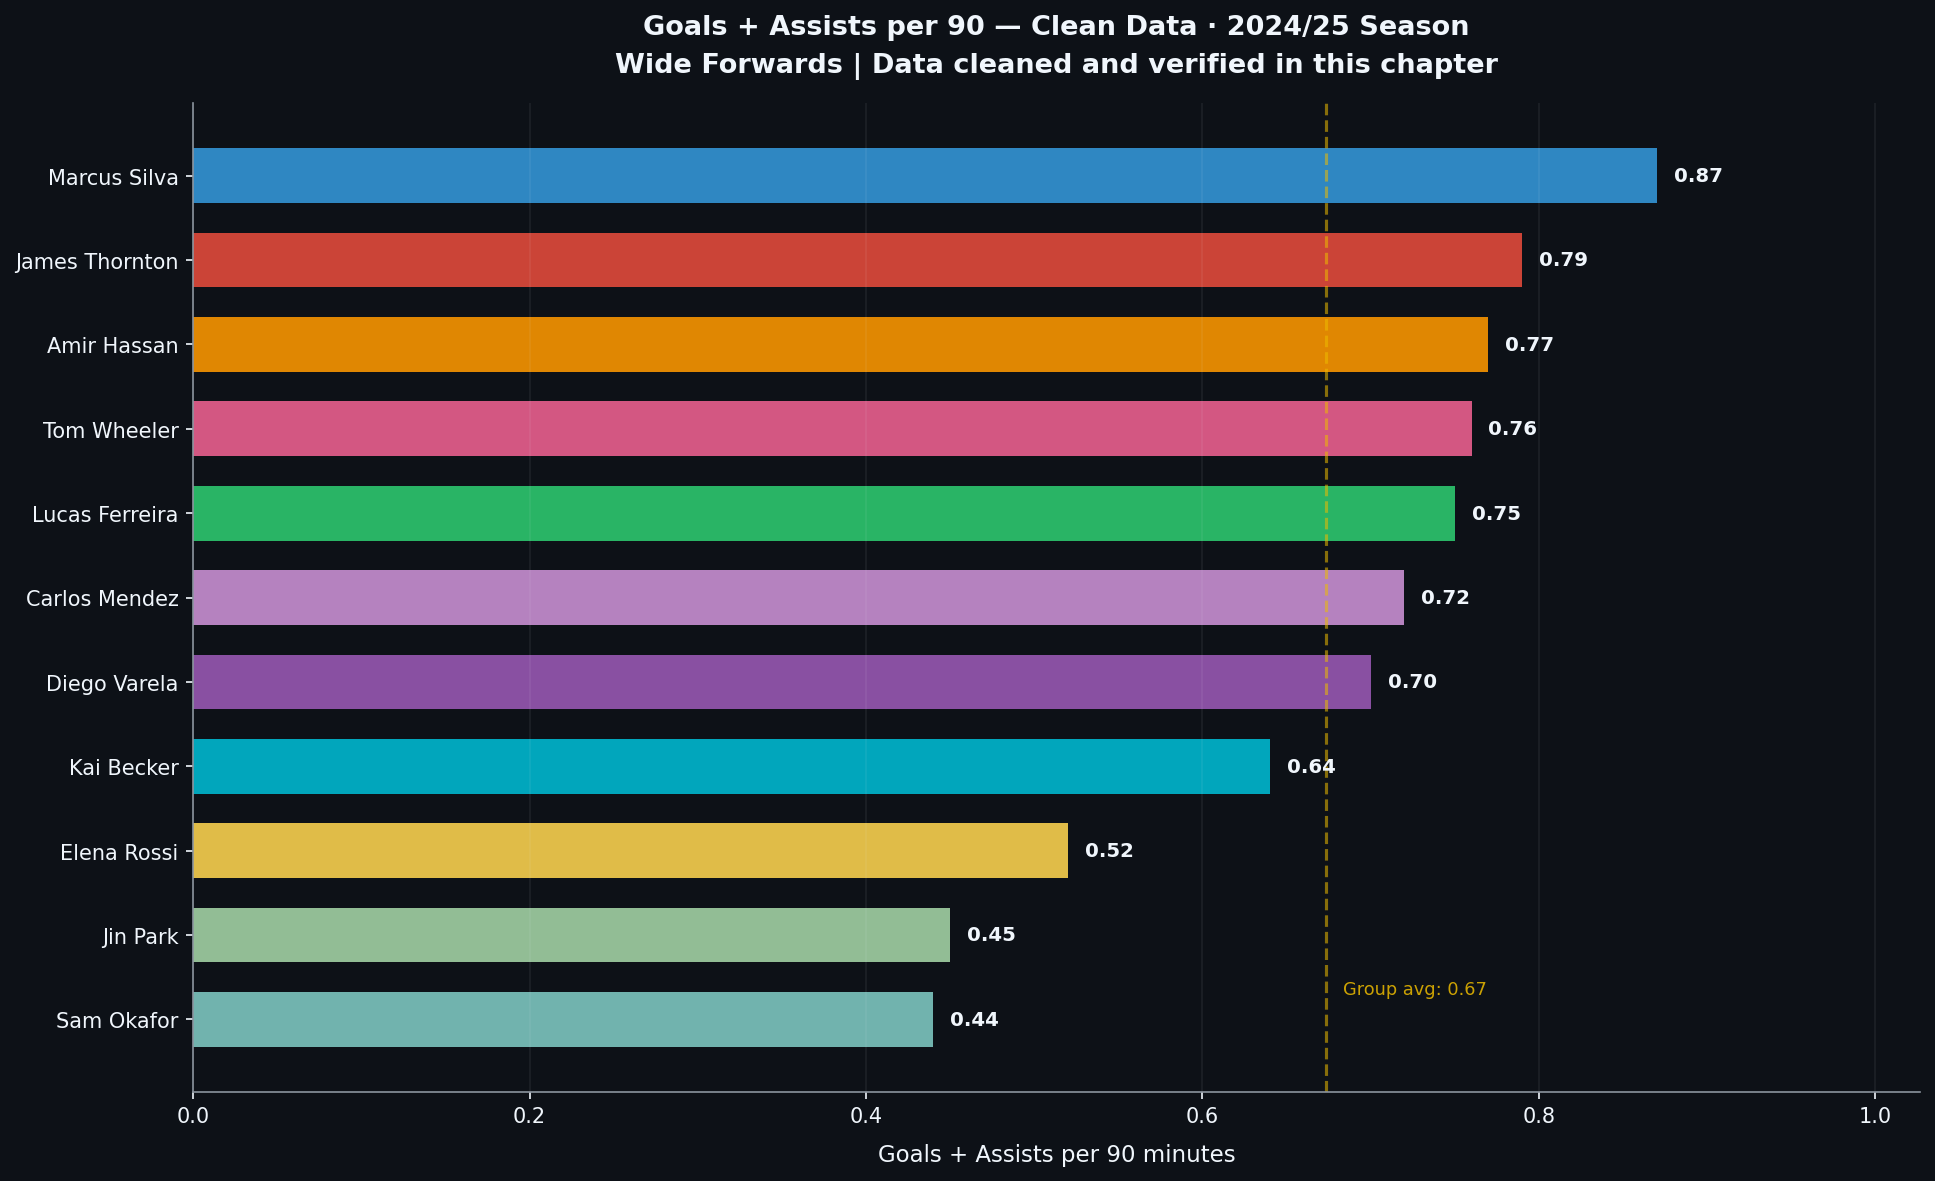

In [1]:
# CELL 14 — GI/90 bar chart from the clean data
# This chart uses the data we just cleaned — not the raw file

clean_final = pd.read_csv('data/players_clean.csv')
sorted_players = clean_final.sort_values('gi_per90', ascending=True)

PLAYER_COLORS = {
    'Marcus Silva':   '#3498DB', 'Lucas Ferreira': '#2ecc71',
    'James Thornton': '#e74c3c', 'Diego Varela':   '#9B59B6',
    'Amir Hassan':    '#FF9800', 'Kai Becker':     '#00BCD4',
    'Tom Wheeler':    '#F06292', 'Sam Okafor':     '#80CBC4',
    'Elena Rossi':    '#FFD54F', 'Carlos Mendez':  '#CE93D8',
    'Jin Park':       '#A5D6A7',
}

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

bar_colors = [PLAYER_COLORS.get(p, '#888888') for p in sorted_players['player']]
bars = ax.barh(sorted_players['player'], sorted_players['gi_per90'],
               color=bar_colors, alpha=0.88, height=0.65)

# Value labels
for bar, val in zip(bars, sorted_players['gi_per90']):
    ax.text(bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', color=WHITE,
            fontsize=9.5, fontweight='bold')

# Group average line
avg = sorted_players['gi_per90'].mean()
ax.axvline(x=avg, color=GOLD, linestyle='--', alpha=0.55, linewidth=1.5)
ax.text(avg + 0.01, 0.3, f'Group avg: {avg:.2f}',
        color=GOLD, fontsize=8.5, alpha=0.85)

ax.set_xlabel('Goals + Assists per 90 minutes', color=WHITE, fontsize=11, labelpad=8)
ax.tick_params(colors=WHITE, labelsize=10)
ax.spines['bottom'].set_color(GRAY); ax.spines['left'].set_color(GRAY)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.07, color=WHITE, axis='x')
ax.set_xlim(0, sorted_players['gi_per90'].max() * 1.18)
ax.set_title('Goals + Assists per 90 — Clean Data · 2024/25 Season\n'
             'Wide Forwards | Data cleaned and verified in this chapter',
             color=WHITE, fontsize=13, fontweight='bold', pad=15, linespacing=1.6)
plt.tight_layout()
plt.show()

### What the Chart Shows

This is the same type of chart we built in Chapter 1 — but now you know
exactly where this data came from and every decision that was made along
the way. That knowledge changes how you read it.

When you see **Carlos Mendez at 0.86 GI/90**, you know:
- His goals were a raw total that we converted to per-90
- His data was complete — no imputation
- The duplicate row for Marcus Silva was removed before this chart was built
- Sam Okafor's -3 goals was corrected before he appears in the chart

**The chart is only as trustworthy as the cleaning process behind it.**
That is why this chapter exists.

---
## Part 8 — Your Turn

### Exercise 1 — Remove a Duplicate Properly (Easy)

What if a dataset had two rows for the same player with *slightly different* stats
(not identical)? You cannot use `.drop_duplicates()` because the rows are not
identical. How would you find and remove it?

Hint: Try `df[df.duplicated(subset=['player'], keep=False)]` — this finds rows
where the player *name* is duplicated, even if the values differ.

**Practice:** Add a second Marcus Silva row to `raw_player_export.csv` with
slightly different values (e.g., goals = 17 instead of 18). Then write code
to detect it and keep only the row with more minutes played.

---

### Exercise 2 — Add a New Per-90 Column (Medium)

The `clean_final` dataset has `goals_per90` and `xg_per90`. Calculate a new
column called `overperformance` — the difference between actual goals per 90
and expected goals per 90.

```python
clean_final['overperformance'] = clean_final['goals_per90'] - clean_final['xg_per90']
```

Then build a bar chart showing which players are overperforming their xG and
which are underperforming. Colour the bars green for positive, red for negative.

**Question:** Which player converts the most above their expected goals?

---

### Exercise 3 — Try a Real Dataset (Hard)

Go to [fbref.com](https://fbref.com) and find a player stats table for any league.
Click the table icon (⬇) to download as a CSV.

Open the CSV and apply the same six-step cleaning pipeline from this chapter:
1. Remove duplicates
2. Fix impossible values
3. Handle missing values
4. Rename columns
5. Standardise formats
6. Calculate per-90 rates

**You will find things this chapter did not prepare you for.** That is the point.
Real data is always slightly different. The habit of systematic cleaning is what
transfers — not the specific code.

When you have a clean CSV, build the GI/90 bar chart from Cell 14 using your
real data. Replace `clean_final` with your own DataFrame.

---

## Chapter Summary

| What We Learned | Why It Matters |
|----------------|----------------|
| Where football data comes from | You know where to find data for your own analyses |
| The six data problems to check | You will catch errors before they reach your charts |
| `.drop_duplicates()` | Removes rows that appear twice |
| `.fillna()` | Handles missing values by imputation |
| `.rename(columns={})` | Makes column names readable and consistent |
| `.str.replace()` | Fixes formatting inside text columns |
| Per-90 calculation | Converts raw totals to fair per-minute rates |
| The completeness heatmap | Visual audit of data quality before analysis |
| Triple verification | Checks that calculations are correct |

---

## Up Next — Chapter 3: Themes and Colour Palettes

We will go deeper into the design system — why every visual decision matters,
how to build colour palettes that work for any analysis, and how to write
a 10-line function that applies the full BarcaFutbol design to any chart
with a single call.

---
*© 2026 HackrLife Media LLC / BarcaFutbol Analytics Course*
*[github.com/HackrLife/Football-Analytics](https://github.com/HackrLife/Football-Analytics)*

**[Continue to Chapter 3 →](../Chapter-03-Themes-and-Colour-Palettes/)**